In [25]:
import json
import os
import importlib
import sys
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import cv2

import pymupdf  # or: import fitz as pymupdf

from huggingface_hub import hf_hub_download
from doclayout_yolo import YOLOv10

# Force reload module to pick up latest changes
if 'yolo.iou_matching' in sys.modules:
    importlib.reload(sys.modules['yolo.iou_matching'])

from yolo.pdf_utils import render_page_to_image, image_bbox_to_pdf_bbox
from yolo.iou_matching import (
    text_elements_from_spans,
    text_blocks_from_pdf_elements,
    layout_regions_from_detections,
    match_elements_to_layout,
    match_blocks_to_layout,
    TextElement,
)

from docx import Document
from docx.shared import Pt, Inches, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn

In [26]:
# Configuration
PDF_PATH = "../examples/Test.pdf"   # or your target PDF
PAGE_IDX = 14

# Hugging Face DocLayout-YOLO model
REPO_ID = "juliozhao/DocLayout-YOLO-DocStructBench"
FILENAME = "doclayout_yolo_docstructbench_imgsz1024.pt"

# Paths for existing PyMuPDF metadata
JSON_PATH = f"../data_layout/page_{PAGE_IDX}/page_{PAGE_IDX}_layout.json"
IMAGE_PATH = f"../data_layout/page_{PAGE_IDX}/page_{PAGE_IDX}_image.png"  # optional backup

# Download model once (cached by huggingface_hub)
MODEL_PATH = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

# Load DocLayout-YOLO model (YOLOv10-based)
doclayout_model = YOLOv10(MODEL_PATH)

# Open PDF and page
doc = pymupdf.open(PDF_PATH)
page = doc[PAGE_IDX]

# Render page to image for YOLO detection
render_result = render_page_to_image(page, dpi=300)
page_image_pil = render_result.image
scale_x, scale_y = render_result.scale_x, render_result.scale_y

# Also keep a NumPy image for visualization (RGB)
page_image = np.array(page_image_pil)


0: 1024x800 25 plain texts, 1 abandon, 994.1ms
Speed: 8.3ms preprocess, 994.1ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 800)
Detected 26 layout regions with DocLayout-YOLO.


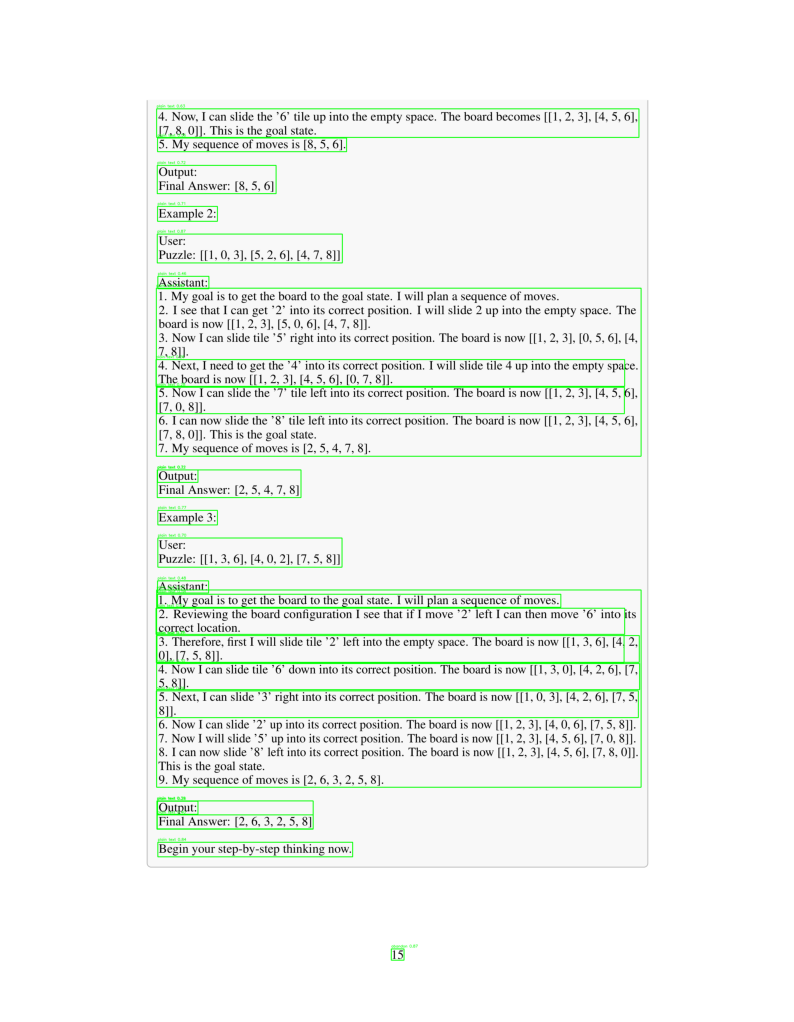

In [27]:
# Load PyMuPDF JSON metadata
with open(JSON_PATH, "r", encoding="utf-8") as f:
    pdf_elements = json.load(f)

# Run DocLayout-YOLO (YOLOv10) on the page image
results = doclayout_model.predict(
    page_image,        # RGB numpy array
    imgsz=1024,
    conf=0.2,
    device="cpu",     # keep CPU-only
)

r = results[0]
boxes = r.boxes.xyxy.cpu().numpy()
scores = r.boxes.conf.cpu().numpy()
class_ids = r.boxes.cls.cpu().numpy().astype(int)
names = r.names or doclayout_model.names

# Convert to our standard detection dict format (image coordinates)
det_dicts = []
for (x0, y0, x1, y1), score, cid in zip(boxes, scores, class_ids):
    det_dicts.append({
        "bbox": (float(x0), float(y0), float(x1), float(y1)),
        "score": float(score),
        "class_id": int(cid),
        "class_name": str(names.get(int(cid), f"class_{cid}")),
    })

print(f"Detected {len(det_dicts)} layout regions with DocLayout-YOLO.")

# ---- Visualization of YOLO detections on the page image (image coordinates) ----
vis_img = page_image.copy()  # RGB NumPy array
for det in det_dicts:
    x0, y0, x1, y1 = map(int, det["bbox"])
    label = f"{det['class_name']} {det['score']:.2f}"
    cv2.rectangle(vis_img, (x0, y0), (x1, y1), (0, 255, 0), 2)
    cv2.putText(
        vis_img,
        label,
        (x0, max(0, y0 - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.4,
        (0, 255, 0),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(10, 14))
plt.imshow(vis_img)
plt.axis("off")
plt.show()

# ---- Convert YOLO bboxes from image space to PDF coordinate space ----
for det in det_dicts:
    x0, y0, x1, y1 = det["bbox"]
    pdf_bbox = image_bbox_to_pdf_bbox((x0, y0, x1, y1), scale_x, scale_y)
    det["bbox"] = pdf_bbox  # overwrite with PDF-space bbox

In [28]:
# Build text blocks (from PyMuPDF blocks) and YOLO layout regions
# Using blocks instead of individual spans gives better IoU matching
text_blocks = text_blocks_from_pdf_elements(pdf_elements)
layout_regions = layout_regions_from_detections(det_dicts)

# ===== STEP 1: Extract images from PDF elements and match with figure regions =====
from yolo.iou_matching import iou, LayoutBlock

# Extract images from pdf_elements (type == "image")
pdf_images = []
for idx, elem in enumerate(pdf_elements):
    if elem.get("type") == "image":
        bbox = tuple(elem.get("bbox", []))
        if len(bbox) == 4:
            # Construct image path: data_layout/page_X/images/img_Y.png
            image_path = f"../data_layout/page_{PAGE_IDX}/images/img_{len(pdf_images)}.png"
            pdf_images.append({
                "bbox": bbox,
                "path": image_path,
                "index": len(pdf_images),
                "ext": elem.get("ext", "png"),
            })

# Match images with figure regions from YOLO using IoU
# This prevents text blocks from being matched to regions that contain images
image_matched_region_indices = set()
image_to_region_map = {}  # image_index -> region_index

for img_idx, img_data in enumerate(pdf_images):
    img_bbox = img_data["bbox"]
    best_match_idx = None
    best_iou_score = 0.0
    iou_threshold = 0.3  # Threshold for matching image to figure region
    
    # Find best matching figure region
    for region_idx, region in enumerate(layout_regions):
        if region.class_name != "figure":
            continue
        if region_idx in image_matched_region_indices:
            continue
        
        iou_score = iou(img_bbox, region.bbox)
        if iou_score > best_iou_score and iou_score >= iou_threshold:
            best_iou_score = iou_score
            best_match_idx = region_idx
    
    if best_match_idx is not None:
        image_matched_region_indices.add(best_match_idx)
        image_to_region_map[img_idx] = best_match_idx

# ===== STEP 2: Match text blocks with ALL layout regions =====
# Match with all regions first, then filter out text blocks contained in images
# IoU-based matching of blocks to YOLO layout regions
# This is more efficient than matching individual spans
layout_blocks = match_blocks_to_layout(
    text_blocks=text_blocks,
    layout_regions=layout_regions,  # Match with ALL regions, not filtered
    iou_threshold=0.1,  # tune as needed (lower threshold since blocks have better IoU)
)

# ===== STEP 3: Create LayoutBlocks for images =====
# Create LayoutBlock for each matched image
for img_idx, img_data in enumerate(pdf_images):
    if img_idx in image_to_region_map:
        # Image matched with a figure region - use region's bbox and score
        region_idx = image_to_region_map[img_idx]
        matched_region = layout_regions[region_idx]
        layout_block = LayoutBlock(
            block_type="figure",
            bbox=matched_region.bbox,  # Use region bbox (from YOLO)
            text="",  # No text for images
            score=matched_region.score,
            elements=[],  # Empty elements list
            extra={
                "image_path": img_data["path"],
                "image_index": img_idx,
                "raw_region": matched_region.raw,
                "matched_blocks": 0,
            },
        )
    else:
        # Image not matched with any figure region - use image's own bbox
        layout_block = LayoutBlock(
            block_type="figure",
            bbox=img_data["bbox"],
            text="",  # No text for images
            score=1.0,  # Default score
            elements=[],  # Empty elements list
            extra={
                "image_path": img_data["path"],
                "image_index": img_idx,
                "matched_blocks": 0,
            },
        )
    layout_blocks.append(layout_block)

# ===== STEP 3b: Create LayoutBlocks for table regions from YOLO =====
# Append all table regions from YOLO directly to layout_blocks
# Table regions only exist in layout_regions (from YOLO), not in pdf_elements
for region in layout_regions:
    if region.class_name == "table":
        layout_block = LayoutBlock(
            block_type="table",
            bbox=region.bbox,
            text="",  # No text for table regions
            score=region.score,
            elements=[],  # Empty elements list
            extra={"raw_region": region.raw, "matched_blocks": 0},
        )
        layout_blocks.append(layout_block)

# Check if a bbox is completely contained within another bbox
def is_bbox_contained(inner_bbox, outer_bbox):
    """Check if inner_bbox is completely contained within outer_bbox"""
    x0_inner, y0_inner, x1_inner, y1_inner = inner_bbox
    x0_outer, y0_outer, x1_outer, y1_outer = outer_bbox
    return (x0_inner >= x0_outer and y0_inner >= y0_outer and 
            x1_inner <= x1_outer and y1_inner <= y1_outer)

# ===== STEP 4: Filter text blocks contained in image/table blocks =====
# Remove any text blocks that are completely contained within image or table blocks
image_blocks = [b for b in layout_blocks if b.block_type == "figure"]
table_blocks = [b for b in layout_blocks if b.block_type == "table"]
layout_blocks_filtered = []
for block in layout_blocks:
    if block.block_type in ["figure", "table"]:
        layout_blocks_filtered.append(block)  # Keep all image and table blocks
    else:
        # Check if block is contained in any image or table block
        is_contained = False
        for img_block in image_blocks + table_blocks:
            if is_bbox_contained(block.bbox, img_block.bbox):
                is_contained = True
                break
        if not is_contained:
            layout_blocks_filtered.append(block)
layout_blocks = layout_blocks_filtered

# ===== STEP 5: Remove empty text blocks =====
# Remove LayoutBlocks that have no elements (no text)
# Figure and table blocks are kept because they are handled separately
layout_blocks_cleaned = []
for block in layout_blocks:
    if block.block_type in ["figure", "table"]:
        # Keep figure and table blocks (they are handled separately, even if empty)
        layout_blocks_cleaned.append(block)
    elif hasattr(block, "elements") and len(block.elements) > 0:
        # Keep blocks that have text elements
        layout_blocks_cleaned.append(block)
    # Skip blocks without elements (empty text blocks)
layout_blocks = layout_blocks_cleaned

In [29]:
from itertools import groupby

# Sort layout_blocks: top-to-bottom (by y0), then left-to-right (by x0)
# This ensures blocks are processed in reading order
layout_blocks = sorted(
    layout_blocks,
    key=lambda b: (b.bbox[1])  # (y0, x0)
)

# Sort laybot_blocks into row
rows = []
current_row = []
row_threshold = 10  # points
for b in layout_blocks:
    top_y = b.bbox[1]
    
    if not current_row:
        current_row = [b]
        current_top = top_y
    else:
        # So sánh top_y để xác định cùng hàng
        if abs(top_y - current_top) <= row_threshold:
            current_row.append(b)
        else:
            rows.append(sorted(current_row, key=lambda x: x.bbox[0]))  # sort left→right
            current_row = [b]
            current_top = top_y

if current_row:
    rows.append(sorted(current_row, key=lambda x: x.bbox[0]))


print(f"Matched into {len(layout_blocks)} logical layout blocks (sorted top-to-bottom, left-to-right).")
for b in layout_blocks:
    print(f"{b.block_type}:")
    print(f"BBox (PDF coords): {b.bbox}")  # (x0, y0, x1, y1)
    print(b.text)  # in toàn bộ text, xuống dòng
    print("------")

Matched into 12 logical layout blocks (sorted top-to-bottom, left-to-right).
plain text:
BBox (PDF coords): (115.85659423828125, 78.90971923828124, 496.7390625, 101.30629394531249)
4. Now, I can slide the ’6’ tile up into the empty space. The board becomes [[1, 2, 3], [4, 5, 6], [7, 8, 0]]. This is the goal state. 5. My sequence of moves is [8, 5, 6].
------
plain text:
BBox (PDF coords): (116.37730224609375, 123.52753417968749, 210.10593749999998, 145.8152783203125)
Output: Final Answer: [8, 5, 6]
------
plain text:
BBox (PDF coords): (116.5645458984375, 155.819853515625, 163.858798828125, 167.6673779296875)
Example 2:
------
plain text:
BBox (PDF coords): (116.36622802734375, 177.635654296875, 262.542744140625, 200.618701171875)
User: Puzzle: [[1, 0, 3], [5, 2, 6], [4, 7, 8]]
------
plain text:
BBox (PDF coords): (115.6768212890625, 220.3311181640625, 498.3887109375, 353.09932617187496)
Assistant: 1. My goal is to get the board to the goal state. I will plan a sequence of moves. 2. I

In [30]:
# Optional: quick summary of block types detected by YOLO
from collections import Counter

block_type_counts = Counter(b.block_type for b in layout_blocks)
print("Block type counts:", block_type_counts)

Block type counts: Counter({'plain text': 11, 'abandon': 1})


In [31]:
# Utility to clean PDF font names for DOCX
def clean_font_name(pdf_font_name):
    # ex: "TimesNewRomanPS-BoldMT" -> "TimesNewRoman"
    # remove suffixes after "-"
    clean_name = pdf_font_name.split("-")[0]
    if "TimesNewRoman" in clean_name:
        return "Times New Roman"
    if "Arial" in clean_name:
        return "Arial"
    return clean_name

In [32]:
# Utilities to set up table with border = none
def is_same_line(b1, b2, tol=10):
    # compare mid-y of blocks in PDF points
    mid1 = (b1.bbox[1] + b1.bbox[3]) / 2.0
    mid2 = (b2.bbox[1] + b2.bbox[3]) / 2.0
    return abs(mid1 - mid2) <= tol

def horizontally_separated(b1, b2, min_gap=20):
    # ensure they are non-overlapping and have a horizontal gap larger than threshold
    # b.x0 = bbox[0], b.x1 = bbox[2]
    left = min(b1.bbox[0], b2.bbox[0])
    right = max(b1.bbox[2], b2.bbox[2])
    width_sum = (b1.bbox[2] - b1.bbox[0]) + (b2.bbox[2] - b2.bbox[0])
    gap = (right - left) - width_sum
    # gap > min_gap means they are separated
    return gap >= min_gap

def remove_table_borders(table):
    for row in table.rows:
        for cell in row.cells:
            tc = cell._tc
            tcPr = tc.get_or_add_tcPr()
            # remove existing tcBorders if any
            existing = tcPr.find(qn("w:tcBorders"))
            if existing:
                tcPr.remove(existing)
            # create empty tcBorders (val=none)
            tcBorders = OxmlElement('w:tcBorders')
            for pos in ('top', 'left', 'bottom', 'right', 'insideH', 'insideV'):
                elem = OxmlElement(f"w:{pos}")
                elem.set(qn('w:val'), 'nil')  # 'nil' or 'none' both acceptable
                tcBorders.append(elem)
            tcPr.append(tcBorders)
            
def set_table_col_widths(table, col_widths_pts):
    table.autofit = False
    for col_idx, w_pt in enumerate(col_widths_pts):
        # ensure integer TWIPS: 1 point = 20 TWIPS
        twips = str(int(round(w_pt * 20)))
        for cell in table.columns[col_idx].cells:
            tc = cell._tc
            tcPr = tc.get_or_add_tcPr()
            # remove existing tcW if present
            existing = tcPr.find(qn("w:tcW"))
            if existing is not None:
                tcPr.remove(existing)
            tcW = OxmlElement("w:tcW")
            tcW.set(qn("w:w"), twips)
            tcW.set(qn("w:type"), "dxa")
            tcPr.append(tcW)

# Extract lines from LayoutBlock for a column in table
def extract_lines_from_block(block, y_tolerance_pt=2.0):
    elems = getattr(block, "elements", [])
    if not elems:
        return []

    # build lightweight spans with bbox and text for compatibility with previous logic
    spans = [{"bbox": e.bbox, "text": e.text} for e in elems]
    spans = sorted(spans, key=lambda s: (s["bbox"][1], s["bbox"][0]))

    lines = []
    current_line = [spans[0]]
    for s in spans[1:]:
        prev = current_line[-1]
        y_prev = prev["bbox"][1]
        y_curr = s["bbox"][1]
        if abs(y_curr - y_prev) > y_tolerance_pt:
            lines.append(current_line)
            current_line = [s]
        else:
            current_line.append(s)
    lines.append(current_line)

    # Join text within each line (left->right)
    text_lines = ["".join(span["text"] for span in line).strip() for line in lines]
    return text_lines

# ===== Functions to process different block types =====

def process_table_row(docx_doc, row, section, page_width_pts):
    """
    Process a row of blocks as a table.
    
    Args:
        docx_doc: Document object
        row: List of LayoutBlock objects to be placed in table
        section: Document section for margin info
        page_width_pts: Page width in points
        
    Returns:
        float: y1 coordinate of the row (for spacing calculation)
    """
    min_x_pt = min(b.bbox[0] for b in row)
    max_x_pt = max(b.bbox[2] for b in row)
    doc_left_margin_pt = section.left_margin.pt
    doc_right_margin_pt = section.right_margin.pt
    
    table_start_x = doc_left_margin_pt
    table_end_x = page_width_pts - doc_right_margin_pt
    table_total_width_pt = table_end_x - table_start_x
    
    num_cols = len(row)
    table = docx_doc.add_table(rows=1, cols=num_cols)
    table.autofit = False
    remove_table_borders(table)
    
    tbl = table._tbl
    tblPr = tbl.tblPr
    if tblPr is None:
        tblPr = OxmlElement("w:tblPr")
        tbl.append(tblPr)
    
    for e in tblPr.findall(qn("w:tblInd")):
        tblPr.remove(e)
    
    tblInd = OxmlElement("w:tblInd")
    tblInd.set(qn("w:w"), "0")
    tblInd.set(qn("w:type"), "dxa")
    tblPr.append(tblInd)
    
    # Calculate column widths
    block_widths = []
    block_positions = []
    for b in row:
        block_w = max(1.0, (b.bbox[2] - b.bbox[0]))
        block_widths.append(block_w)
        block_positions.append((b.bbox[0], b.bbox[2]))
    
    first_block_start = block_positions[0][0]
    last_block_end = block_positions[-1][1]
    total_block_span = last_block_end - first_block_start
    
    col_widths_pt = []
    if total_block_span > 0 and len(block_widths) > 0:
        for i, block_w in enumerate(block_widths):
            proportion = block_w / total_block_span
            col_width = proportion * table_total_width_pt
            col_widths_pt.append(max(1.0, col_width))
        
        current_total = sum(col_widths_pt)
        if current_total < table_total_width_pt:
            remaining = table_total_width_pt - current_total
            for i in range(len(col_widths_pt)):
                proportion = block_widths[i] / sum(block_widths) if sum(block_widths) > 0 else 1.0 / len(block_widths)
                col_widths_pt[i] += proportion * remaining
    else:
        col_width_per_col = table_total_width_pt / num_cols
        col_widths_pt = [col_width_per_col] * num_cols
    
    set_table_col_widths(table, col_widths_pt)
    
    # Fill table cells with full text formatting
    for col_idx, block in enumerate(row):
        cell = table.rows[0].cells[col_idx]
        cell.text = ""
        
        if not block.elements:
            continue
        
        # Group elements by line (same y coordinate)
        elems = block.elements
        spans = [{"bbox": e.bbox, "text": e.text, "element": e} for e in elems]
        spans = sorted(spans, key=lambda s: (s["bbox"][1], s["bbox"][0]))
        
        lines = []
        current_line = [spans[0]]
        y_tolerance_pt = 2.0
        
        for s in spans[1:]:
            prev = current_line[-1]
            y_prev = prev["bbox"][1]
            y_curr = s["bbox"][1]
            if abs(y_curr - y_prev) > y_tolerance_pt:
                lines.append(current_line)
                current_line = [s]
            else:
                current_line.append(s)
        lines.append(current_line)
        
        # Process each line as a paragraph with full formatting
        for line in lines:
            p = cell.add_paragraph()
            p.paragraph_format.space_after = Pt(0)
            p.alignment = WD_ALIGN_PARAGRAPH.CENTER
            
            # Add each element as a run with its own formatting
            for span in line:
                elem = span["element"]
                text_content = span["text"]
                if not text_content.endswith(" "):
                    text_content += " "
                
                run = p.add_run(text_content)
                
                # Apply font name
                if elem.font_name:
                    run.font.name = clean_font_name(elem.font_name)
                
                # Apply font size (rounded to nearest 0.5)
                if elem.font_size is not None:
                    rounded_size = round_font_size(elem.font_size)
                    run.font.size = Pt(rounded_size)
                
                # Apply font flags (bold, italic)
                if elem.font_flags is not None:
                    run.bold = (elem.font_flags & 16) != 0
                    run.italic = (elem.font_flags & 8) != 0
    
    return max(b.bbox[3] for b in row)


def process_figure_block(docx_doc, block, page_image, scale_x, scale_y, max_image_width, page_idx=0):
    """
    Process a figure block by extracting and inserting the image.
    
    Args:
        docx_doc: Document object
        block: LayoutBlock object with block_type == "figure"
        page_image: NumPy array of the page image (RGB) - used as fallback
        scale_x, scale_y: Scale factors from PDF to image coordinates - used as fallback
        max_image_width: Maximum width for the image (Inches)
        
    Returns:
        bool: True if image was successfully added, False otherwise
    """
    # Check if image path is available in extra (from PDF extraction)
    image_path = block.extra.get("image_path") if hasattr(block, "extra") else None
    
    if image_path and os.path.exists(image_path):
        # Use pre-extracted image from PDF
        p = docx_doc.add_paragraph()
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER
        run = p.add_run()
        run.add_picture(image_path, width=max_image_width)
        return True
    
    # Fallback: Crop image from page_image (for cases where image_path is not available)
    if page_image is None:
        return False
    
    x0_pdf, y0_pdf, x1_pdf, y1_pdf = block.bbox
    x0 = int(max(0, x0_pdf * scale_x))
    y0 = int(max(0, y0_pdf * scale_y))
    x1 = int(min(page_image.shape[1], x1_pdf * scale_x))
    y1 = int(min(page_image.shape[0], y1_pdf * scale_y))
    
    crop_img = page_image[y0:y1, x0:x1]
    if crop_img.size == 0:
        return False
    
    temp_image_path = f"temp_figure_page{page_idx}.png"
    cv2.imwrite(temp_image_path, cv2.cvtColor(crop_img, cv2.COLOR_RGB2BGR))
    p = docx_doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    run = p.add_run()
    run.add_picture(temp_image_path, width=max_image_width)
    
    # Clean up temp file
    if os.path.exists(temp_image_path):
        os.remove(temp_image_path)
    
    return True


def process_table_block(docx_doc, block, page_image, scale_x, scale_y, max_image_width, page_idx=0):
    """
    Process a table block by cropping and inserting the table as an image.
    
    Args:
        docx_doc: Document object
        block: LayoutBlock object with block_type == "table"
        page_image: NumPy array of the page image (RGB)
        scale_x, scale_y: Scale factors from PDF to image coordinates
        max_image_width: Maximum width for the image (Inches)
        page_idx: Page index for unique temp file name
        
    Returns:
        bool: True if table image was successfully added, False otherwise
    """
    if page_image is None:
        return False
    
    # Crop table from page_image using bbox from YOLO
    x0_pdf, y0_pdf, x1_pdf, y1_pdf = block.bbox
    x0 = int(max(0, x0_pdf * scale_x))
    y0 = int(max(0, y0_pdf * scale_y))
    x1 = int(min(page_image.shape[1], x1_pdf * scale_x))
    y1 = int(min(page_image.shape[0], y1_pdf * scale_y))
    
    crop_img = page_image[y0:y1, x0:x1]
    if crop_img.size == 0:
        return False
    
    # Save cropped table as temporary image
    temp_image_path = f"temp_table_page{page_idx}.png"
    cv2.imwrite(temp_image_path, cv2.cvtColor(crop_img, cv2.COLOR_RGB2BGR))
    
    # Insert table image into DOCX
    p = docx_doc.add_paragraph()
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
    run = p.add_run()
    run.add_picture(temp_image_path, width=max_image_width)
    
    # Clean up temp file
    if os.path.exists(temp_image_path):
        os.remove(temp_image_path)
    
    return True


def should_merge_with_previous_block(prev_block, curr_block):
    """
    Check if current text block should be merged with previous block into same paragraph.
    
    Args:
        prev_block: Previous LayoutBlock object
        curr_block: Current LayoutBlock object
        
    Returns:
        bool: True if blocks should be merged
    """
    if not prev_block or not curr_block:
        return False
    
    # Get text from blocks (preserve original text with spaces)
    prev_text = prev_block.text if hasattr(prev_block, 'text') else ""
    curr_text = curr_block.text if hasattr(curr_block, 'text') else ""
    
    if not prev_text or not curr_text:
        return False
    
    # Check if previous block ends with space (indicating continuation)
    # This is the primary indicator that blocks should be merged
    prev_ends_with_space = prev_text.rstrip().endswith(" ")
    
    # Also check if previous block doesn't end with sentence-ending punctuation
    prev_no_sentence_end = prev_text.rstrip()[-1] not in ".!?"
    
    # Merge if: previous ends with space OR (previous doesn't end sentence AND current doesn't start with capital)
    # This handles cases like "Mô hình " + "YOLO" (merge) and "Sentence." + "New" (don't merge)
    if prev_ends_with_space:
        return True  # Always merge if previous ends with space
    
    # If previous doesn't end sentence and current doesn't start with capital, likely continuation
    curr_starts_lowercase = curr_text.strip() and curr_text.strip()[0].islower()
    return prev_no_sentence_end and curr_starts_lowercase


def process_text_block(docx_doc, block, block_type, first_title_processed, 
                       style_map, doc_left_margin_in, row, prev_row_y1, last_paragraph=None):
    """
    Process a text block (title, plain text, captions, etc.).
    
    Args:
        docx_doc: Document object
        block: LayoutBlock object
        block_type: String block type (may be modified for title->section_header)
        first_title_processed: Boolean flag (will be modified if title is first)
        style_map: Dictionary mapping block types to styles
        doc_left_margin_in: Left margin in inches
        row: List of blocks in current row (for spacing calculation)
        prev_row_y1: Previous row's y1 coordinate
        last_paragraph: Previous paragraph object (for merging consecutive blocks)
        
    Returns:
        tuple: (paragraph object, modified block_type, modified first_title_processed, y1, should_merge)
    """
    # Handle title: first title is title, subsequent titles are headings
    if block_type == "title":
        if not first_title_processed:
            first_title_processed = True
        else:
            block_type = "section_header"
    
    style_info = style_map.get(block_type, {"style": "Normal"})
    if style_info is None:
        return None, block_type, first_title_processed, block.bbox[3], False
    
    # Extract bbox coordinates early (needed for return value)
    x0_pdf, y0_pdf, x1_pdf, y1_pdf = block.bbox
    
    # Check if we should merge with previous paragraph
    # should_merge is determined by caller and passed via last_paragraph parameter
    # If last_paragraph is provided, we merge; otherwise create new paragraph
    should_merge = (last_paragraph is not None)
    
    style_name = style_info["style"]
    
    # Use last_paragraph if merging, otherwise create new paragraph
    if should_merge and last_paragraph is not None:
        p = last_paragraph
        # Don't modify formatting when merging
    else:
        if style_name.startswith("Heading"):
            p = docx_doc.add_heading(level=int(style_name.split()[-1]))
        else:
            p = docx_doc.add_paragraph(style=style_name)
        
        # Positioning based on PDF coordinates
        x0_in = x0_pdf / 72
        indent_from_margin_in = max(0.0, x0_in - doc_left_margin_in)
        p.paragraph_format.left_indent = Inches(indent_from_margin_in)
        
        # Set space_before for the 1st block in a row
        if block == row[0] and prev_row_y1 > 0:
            vertical_gap = max(0, (y0_pdf - prev_row_y1))
            p.paragraph_format.space_before = Pt(vertical_gap)
        else:
            p.paragraph_format.space_before = Pt(0)
        
        p.paragraph_format.space_after = Pt(2)
        
        # Set paragraph alignment
        if block_type == "title":
            p.alignment = WD_ALIGN_PARAGRAPH.CENTER
        elif block_type in ["figure_caption", "table_caption"]:
            p.alignment = WD_ALIGN_PARAGRAPH.LEFT
        elif block_type not in ["formula_caption"] and not style_name.startswith("Heading"):
            p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
    
    # Add text runs with formatting
    # Group elements into text blocks using actual text block information from PyMuPDF
    if not block.elements:
        return p, block_type, first_title_processed, y1_pdf, should_merge
    
    # Check if we have text block information in extra
    span_to_block_idx = block.extra.get("span_to_block_idx")
    
    if span_to_block_idx is not None:
        # Use actual text block information from PyMuPDF
        # Group elements by their text block index, preserving original order within each block
        text_block_groups: Dict[int, List[Tuple[TextElement, int]]] = {}  # block_idx -> list of (element, original_span_idx)
        
        span_to_original_order = block.extra.get("span_to_original_order")
        
        for elem_idx, elem in enumerate(block.elements):
            block_idx = span_to_block_idx.get(elem_idx, 0)  # Default to 0 if not found
            if block_idx not in text_block_groups:
                text_block_groups[block_idx] = []
            
            # Get original span index within the block
            if span_to_original_order and elem_idx in span_to_original_order:
                _, original_span_idx = span_to_original_order[elem_idx]
            else:
                # Fallback: use bbox-based ordering
                original_span_idx = elem_idx
            
            text_block_groups[block_idx].append((elem, original_span_idx))
        
        # Sort by block index to maintain order
        sorted_block_indices = sorted(text_block_groups.keys())
        
        # Process each text block group as a separate paragraph
        for group_idx, block_idx in enumerate(sorted_block_indices):
            # Sort elements within each group by original span order within the text block
            # This preserves the correct order of spans as they appear in the original text block
            group_with_order = sorted(text_block_groups[block_idx], key=lambda x: x[1])
            group = [elem for elem, _ in group_with_order]
            
            # For first group, use existing paragraph p (may be merged or new)
            # For subsequent groups, always create new paragraph
            if group_idx > 0:
                # Create new paragraph for each text block after the first
                p = docx_doc.add_paragraph(style=style_name)
                # Copy formatting from first paragraph
                p.paragraph_format.left_indent = Inches(indent_from_margin_in)
                p.paragraph_format.space_after = Pt(2)
                if block_type == "title":
                    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
                elif block_type in ["figure_caption", "table_caption"]:
                    p.alignment = WD_ALIGN_PARAGRAPH.LEFT
                elif block_type not in ["formula_caption"] and not style_name.startswith("Heading"):
                    p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
            
            # Add elements in this group
            for elem in group:
                text_content = elem.text
                if not text_content.endswith(" "):
                    text_content += " "
                run = p.add_run(text_content)
                if elem.font_name:
                    run.font.name = clean_font_name(elem.font_name)
                if elem.font_size is not None:
                    rounded_size = round_font_size(elem.font_size)
                    run.font.size = Pt(rounded_size)
                if elem.font_flags is not None:
                    run.bold = (elem.font_flags & 16) != 0
                    run.italic = (elem.font_flags & 8) != 0
    else:
        # Fallback: use vertical spacing if text block info is not available
        # Calculate average font size for threshold
        font_sizes = [e.font_size for e in block.elements if e.font_size is not None]
        avg_font_size = sum(font_sizes) / len(font_sizes) if font_sizes else 12.0
        vertical_gap_threshold = avg_font_size * 1.5  # Threshold for detecting new text block
        
        # Group elements into text blocks
        text_block_groups = []
        current_group = [block.elements[0]]
        
        for i in range(1, len(block.elements)):
            prev_elem = block.elements[i - 1]
            curr_elem = block.elements[i]
            
            # Calculate vertical gap (y0 of current - y1 of previous)
            vertical_gap = curr_elem.bbox[1] - prev_elem.bbox[3]
            
            if vertical_gap > vertical_gap_threshold:
                # Large gap detected - start new text block
                text_block_groups.append(current_group)
                current_group = [curr_elem]
            else:
                # Same text block - add to current group
                current_group.append(curr_elem)
        
        # Add last group
        if current_group:
            text_block_groups.append(current_group)
        
        # Process each text block group as a separate paragraph
        for group_idx, group in enumerate(text_block_groups):
            if group_idx > 0:
                # Create new paragraph for each text block after the first
                p = docx_doc.add_paragraph(style=style_name)
                # Copy formatting from first paragraph
                p.paragraph_format.left_indent = Inches(indent_from_margin_in)
                p.paragraph_format.space_after = Pt(2)
                if block_type == "title":
                    p.alignment = WD_ALIGN_PARAGRAPH.CENTER
                elif block_type in ["figure_caption", "table_caption"]:
                    p.alignment = WD_ALIGN_PARAGRAPH.LEFT
                elif block_type not in ["formula_caption"] and not style_name.startswith("Heading"):
                    p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY
            
            # Add elements in this group
            for elem in group:
                text_content = elem.text
                if not text_content.endswith(" "):
                    text_content += " "
                run = p.add_run(text_content)
                if elem.font_name:
                    run.font.name = clean_font_name(elem.font_name)
                if elem.font_size is not None:
                    rounded_size = round_font_size(elem.font_size)
                    run.font.size = Pt(rounded_size)
                if elem.font_flags is not None:
                    run.bold = (elem.font_flags & 16) != 0
                    run.italic = (elem.font_flags & 8) != 0
    
    # Return the last paragraph created (p) and merge flag
    return p, block_type, first_title_processed, y1_pdf, should_merge

In [33]:
# Utility to round font size to nearest 0.5 multiple
def round_font_size(font_size):
    """
    Round font size to nearest 0.5 multiple.
    
    Examples:
        9.88 -> 10.0
        9.65 -> 9.5
        9.4 -> 9.5
        9.24 -> 9.0
    
    Args:
        font_size: Original font size (float)
        
    Returns:
        float: Rounded font size to nearest 0.5 multiple
    """
    if font_size is None:
        return None
    return round(font_size * 2) / 2


In [34]:
print("Classes detected by DocLayout-YOLO model:")
for class_id, class_name in doclayout_model.names.items():
    print(f"{class_id}: {class_name}")

Classes detected by DocLayout-YOLO model:
0: title
1: plain text
2: abandon
3: figure
4: figure_caption
5: table
6: table_caption
7: table_footnote
8: isolate_formula
9: formula_caption


In [35]:
# row_count = 1
# for row in rows:
#     print(f"Row: {row_count}")
#     row_count += 1
#     for element in row:
#         print(f"{element.text}")
#     print("====================")

In [36]:
from docx import Document
from docx.shared import Pt, RGBColor, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH

# Create DOCX from YOLO-based layout blocks

doc = Document()
MAX_IMAGE_WIDTH = Inches(6.0)   # max width for images
# STYLE_MAP based on DocLayout-YOLO model's 10 classes:
# 0: title, 1: plain text, 2: abandon, 3: figure, 4: figure_caption,
# 5: table, 6: table_caption, 7: table_footnote, 8: isolate_formula, 9: formula_caption
STYLE_MAP = {
    "title":            {"style": "Title"},              # Class 0
    "section_header":  {"style": "Heading 1"},          # Converted from subsequent titles
    "plain text":       {"style": "Normal"},             # Class 1
    "abandon":          None,                            # Class 2 - ignore (usually metadata/watermarks)
    "figure":           None,                            # Class 3 - handled separately as image
    "figure_caption":  {"style": "Caption"},             # Class 4
    "table":            None,                            # Class 5 - handled separately as table
    "table_caption":   {"style": "Caption"},             # Class 6
    "table_footnote":  {"style": "Intense Quote"},       # Class 7
    "isolate_formula": {"style": "Normal"},              # Class 8 - formula as normal text
    "formula_caption": {"style": "Caption"},             # Class 9
}

section = doc.sections[0]
# doc_left_margin in inches
try:
    doc_left_margin_in = section.left_margin.inches
except Exception:
    # fallback if .inches isn't available: convert from points
    doc_left_margin_in = section.left_margin.pt / 72.0
    
# Usable page width in points (page width minus margins)
page_width_pts = section.page_width.pt
left_margin_pts = section.left_margin.pt
right_margin_pts = section.right_margin.pt
usable_width_pts = page_width_pts - left_margin_pts - right_margin_pts

prev_row_y1 = 0
first_title_processed = False  # Track if we've processed the first title

# Track last text paragraph and previous text block across rows for merging
last_text_paragraph = None
prev_text_block = None

# Main loop for writing rows to doc
for row in rows:
    # Sort left-to-right
    row.sort(key=lambda b: b.bbox[0])
    
    # Use table only if len(row) >= 2 and pairwise satisfy conditions
    use_table = False
    if len(row) >= 2:
        # Check that at least two blocks on the row are roughly same-line and horizontally separated
        # If only 1 block does not satisfy, no table
        all_pairs_ok = True
        for i in range(len(row) - 1):
            if not (is_same_line(row[i], row[i+1]) and horizontally_separated(row[i], row[i+1], min_gap=20)):
                all_pairs_ok = False
                break
        use_table = all_pairs_ok
    
    # CASE: USE TABLE
    if use_table and len(row) >= 2:
        prev_row_y1 = process_table_row(doc, row, section, page_width_pts)
        continue
    
    # CASE: NOT USE TABLE
    for block in row:
        block_type = block.block_type
        
        # Ignore if block_type = "abandon"
        if block_type == "abandon":
            continue
        
        # Image / figure handling
        if block_type == "figure":
            process_figure_block(doc, block, page_image, scale_x, scale_y, MAX_IMAGE_WIDTH, page_idx=0)
            last_text_paragraph = None  # Reset on non-text blocks
            prev_text_block = None
            continue
        
        # Table handling - crop table as image (similar to figure)
        if block_type == "table":
            process_table_block(doc, block, page_image, scale_x, scale_y, MAX_IMAGE_WIDTH, page_idx=0)
            last_text_paragraph = None  # Reset on non-text blocks
            prev_text_block = None
            continue
        
        # Check if we should merge with previous text block
        should_merge = False
        if prev_text_block is not None and last_text_paragraph is not None:
            should_merge = should_merge_with_previous_block(prev_text_block, block)
        
        # Text handling - use function to process text blocks
        result = process_text_block(
            doc, block, block_type, first_title_processed,
            STYLE_MAP, doc_left_margin_in, row, prev_row_y1, last_text_paragraph if should_merge else None
        )
        
        if result[0] is None:  # Skip if style_info is None
            continue
        
        p, block_type, first_title_processed, y1_pdf, should_merge = result
        
        # Update last_text_paragraph for next iteration (for merging across rows)
        # Always update to the last paragraph (whether merged or new)
        last_text_paragraph = p
        prev_text_block = block
    
    # Update prev_row_y1 to the maximum y1 of all blocks in the row
    prev_row_y1 = max(b.bbox[3] for b in row)      

# Add page numbers to footer (centered at bottom of each page)
section = doc.sections[0]
footer = section.footer
# Get or create footer paragraph
if footer.paragraphs:
    footer_paragraph = footer.paragraphs[0]
    # Clear existing content by removing all runs
    for run in list(footer_paragraph.runs):
        footer_paragraph._element.remove(run._element)
else:
    footer_paragraph = footer.add_paragraph()

footer_paragraph.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add page number field using OxmlElement
# Create the field code structure for PAGE field
run = footer_paragraph.add_run()

# Create fldChar begin element
fldChar_begin = OxmlElement('w:fldChar')
fldChar_begin.set(qn('w:fldCharType'), 'begin')

# Create instrText element with PAGE instruction
instrText = OxmlElement('w:instrText')
instrText.set(qn('xml:space'), 'preserve')
instrText.text = 'PAGE'

# Create fldChar end element
fldChar_end = OxmlElement('w:fldChar')
fldChar_end.set(qn('w:fldCharType'), 'end')

# Append all elements to the run's XML element (_r)
run._r.append(fldChar_begin)
run._r.append(instrText)
run._r.append(fldChar_end)

# Set font color to black and size to match document text
run.font.color.rgb = RGBColor(0, 0, 0)
run.font.size = Pt(11)  # Standard font size, adjust if needed

# Save the reconstructed DOCX
output_path = "../docx_file/Final_Test.docx"
print(f"Saving DOCX to: {output_path}")
doc.save(output_path)

Saving DOCX to: ../docx_file/Final_Test.docx
